# Report of students for handling errors

In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
file_path1="sample_data_with_errors.csv"
df=pd.read_csv(file_path1)
print(df)

    Student_ID  Age Marks Attendance_Percentage Department
0          1.0   24   NaN                   NaN        NaN
1          2.0   21    46                   NaN        NaN
2          3.0   28    48                 85.91        NaN
3          4.0  NaN    63                   NaN        NaN
4          5.0  NaN   NaN                  74.1         IT
..         ...  ...   ...                   ...        ...
95        96.0  NaN    97                   NaN        NaN
96         NaN  NaN   NaN                 89.77         IT
97        98.0  NaN   NaN                   NaN        NaN
98         NaN  NaN   NaN                 72.32        NaN
99         NaN  NaN    78                   NaN        NaN

[100 rows x 5 columns]


# Checking null values

In [147]:
print(df.isnull().sum())

Student_ID               58
Age                      52
Marks                    64
Attendance_Percentage    67
Department               59
dtype: int64


# Statistical Summary (Before finding errors)

In [148]:
print(df.describe())

       Student_ID
count   42.000000
mean    46.738095
std     30.584596
min      1.000000
25%     20.500000
50%     47.000000
75%     71.750000
max     98.000000


# Info of Data

In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             42 non-null     float64
 1   Age                    48 non-null     object 
 2   Marks                  36 non-null     object 
 3   Attendance_Percentage  33 non-null     object 
 4   Department             41 non-null     object 
dtypes: float64(1), object(4)
memory usage: 4.0+ KB


# Shape of Data

In [150]:
print("Shape of data(rows,columns):")
print(df.shape)
print("Column names:")
print(df.columns)

Shape of data(rows,columns):
(100, 5)
Column names:
Index(['Student_ID', 'Age', 'Marks', 'Attendance_Percentage', 'Department'], dtype='object')


# Filling Department using mode:

In [151]:
df["Department"]=df["Department"].fillna(df["Department"].mode()[0])
print(df.head(25))

    Student_ID     Age Marks Attendance_Percentage Department
0          1.0      24   NaN                   NaN         DS
1          2.0      21    46                   NaN         DS
2          3.0      28    48                 85.91         DS
3          4.0     NaN    63                   NaN         DS
4          5.0     NaN   NaN                  74.1         IT
5          NaN     NaN   NaN                   NaN         DS
6          7.0      27   NaN                 66.59         DS
7          NaN     NaN   NaN                   NaN         DS
8          9.0     NaN   NaN                   NaN         DS
9          NaN     NaN   NaN                   NaN         DS
10         NaN     NaN    56                    --         SE
11         NaN      25   NaN                   NaN         DS
12         NaN     NaN    74                   NaN         DS
13         NaN     NaN   NaN                 68.75         DS
14         NaN     NaN   NaN                 82.32         SE
15      

# Converting Age column into numeric format:

In [152]:
df["Age"]=pd.to_numeric(df["Age"],errors='coerce')
print(df.head(26))

    Student_ID   Age Marks Attendance_Percentage Department
0          1.0  24.0   NaN                   NaN         DS
1          2.0  21.0    46                   NaN         DS
2          3.0  28.0    48                 85.91         DS
3          4.0   NaN    63                   NaN         DS
4          5.0   NaN   NaN                  74.1         IT
5          NaN   NaN   NaN                   NaN         DS
6          7.0  27.0   NaN                 66.59         DS
7          NaN   NaN   NaN                   NaN         DS
8          9.0   NaN   NaN                   NaN         DS
9          NaN   NaN   NaN                   NaN         DS
10         NaN   NaN    56                    --         SE
11         NaN  25.0   NaN                   NaN         DS
12         NaN   NaN    74                   NaN         DS
13         NaN   NaN   NaN                 68.75         DS
14         NaN   NaN   NaN                 82.32         SE
15        16.0   NaN    98              

# Filling out all Columns:

In [153]:
# 1️⃣ Convert columns to numeric FIRST
cols = ["Age", "Marks", "Attendance_Percentage"]
for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
# 2️⃣ Fill missing values department-wise
df["Age"] = df.groupby("Department")["Age"].transform(lambda x: x.fillna(x.mean()))
df["Marks"] = df.groupby("Department")["Marks"].transform(lambda x: x.fillna(x.mean()))
df["Attendance_Percentage"] = df.groupby("Department")["Attendance_Percentage"].transform(lambda x: x.fillna(x.mean()))
print(df.head(15))

    Student_ID     Age      Marks  Attendance_Percentage Department
0          1.0  24.000  72.636364                 82.910         DS
1          2.0  21.000  46.000000                 82.910         DS
2          3.0  28.000  48.000000                 85.910         DS
3          4.0  23.125  63.000000                 82.910         DS
4          5.0  22.750  69.000000                 74.100         IT
5          NaN  23.125  72.636364                 82.910         DS
6          7.0  27.000  72.636364                 66.590         DS
7          NaN  23.125  72.636364                 82.910         DS
8          9.0  23.125  72.636364                 82.910         DS
9          NaN  23.125  72.636364                 82.910         DS
10         NaN  21.500  56.000000                 91.085         SE
11         NaN  25.000  72.636364                 82.910         DS
12         NaN  23.125  74.000000                 82.910         DS
13         NaN  23.125  72.636364               

In [157]:
df['Student_ID'] = df.index + 1
print(df.head(20))

    Student_ID     Age      Marks  Attendance_Percentage Department
0            1  24.000  72.636364                82.9100         DS
1            2  21.000  46.000000                82.9100         DS
2            3  28.000  48.000000                85.9100         DS
3            4  23.125  63.000000                82.9100         DS
4            5  22.750  69.000000                74.1000         IT
5            6  23.125  72.636364                82.9100         DS
6            7  27.000  72.636364                66.5900         DS
7            8  23.125  72.636364                82.9100         DS
8            9  23.125  72.636364                82.9100         DS
9           10  23.125  72.636364                82.9100         DS
10          11  21.500  56.000000                91.0850         SE
11          12  25.000  72.636364                82.9100         DS
12          13  23.125  74.000000                82.9100         DS
13          14  23.125  72.636364               

In [158]:
df.describe()

,Student_ID,Age,Marks,Attendance_Percentage
count,100.000000,100.000000,99.000000,99.000000
mean,50.500000,23.265250,73.643480,82.951566
std,29.011492,4.566025,19.531356,6.648678
min,1.000000,-5.000000,40.000000,66.590000
25%,25.750000,22.000000,70.818182,81.780000
50%,50.500000,23.125000,72.636364,82.910000
75%,75.250000,23.125000,72.636364,82.910000
max,100.000000,50.000000,200.000000,99.850000


In [159]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             100 non-null    int64  
 1   Age                    100 non-null    float64
 2   Marks                  99 non-null     float64
 3   Attendance_Percentage  99 non-null     float64
 4   Department             100 non-null    object 
dtypes: float64(3), int64(1), object(1)
memory usage: 4.0+ KB


# Histogram (Distribution of Age & Marks)

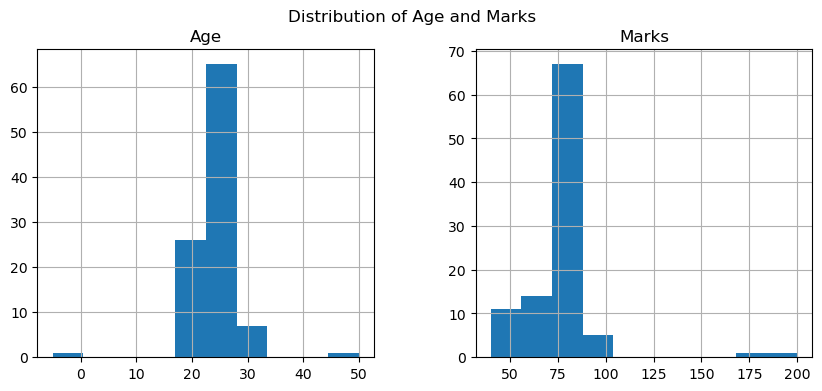

In [160]:
df[['Age', 'Marks']].hist(bins=10, figsize=(10,4))
plt.suptitle("Distribution of Age and Marks")
plt.show()

# Box Plot (Detect Outliers)

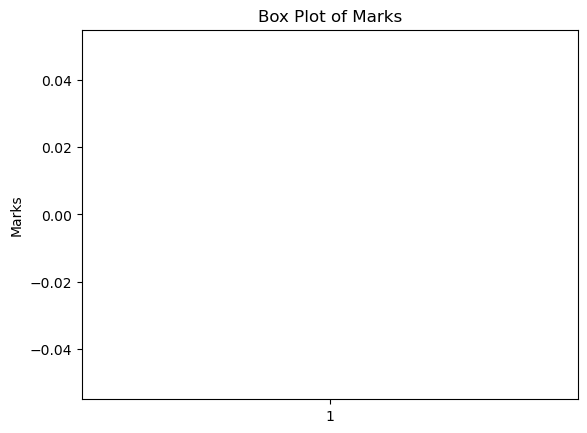

In [165]:
plt.figure()
plt.boxplot(df['Marks'])
plt.title("Box Plot of Marks")
plt.ylabel("Marks")
plt.show()

# Bar Chart (Department-wise Average Marks)

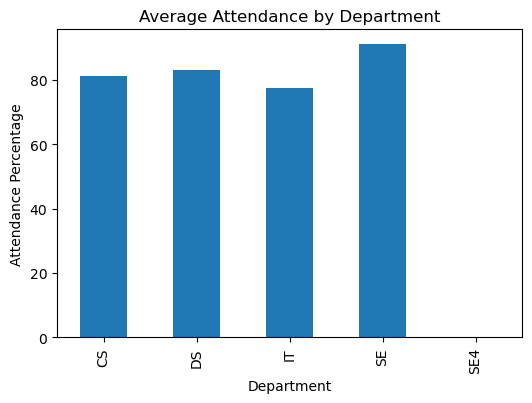

In [162]:
dept_att = df.groupby('Department')['Attendance_Percentage'].mean()

plt.figure(figsize=(6,4))
dept_att.plot(kind='bar')
plt.title("Average Attendance by Department")
plt.xlabel("Department")
plt.ylabel("Attendance Percentage")
plt.show()

# Scatter Plot (Age vs Marks)

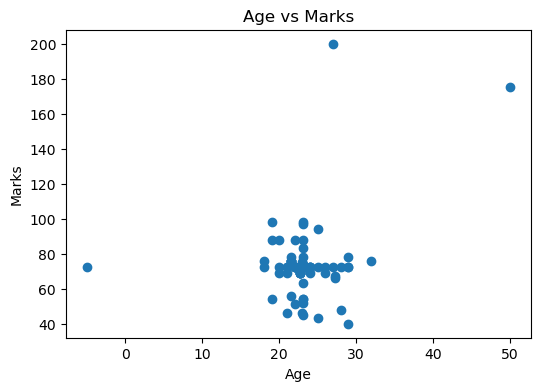

In [163]:
plt.figure(figsize=(6,4))
plt.scatter(df['Age'], df['Marks'])
plt.title("Age vs Marks")
plt.xlabel("Age")
plt.ylabel("Marks")
plt.show()

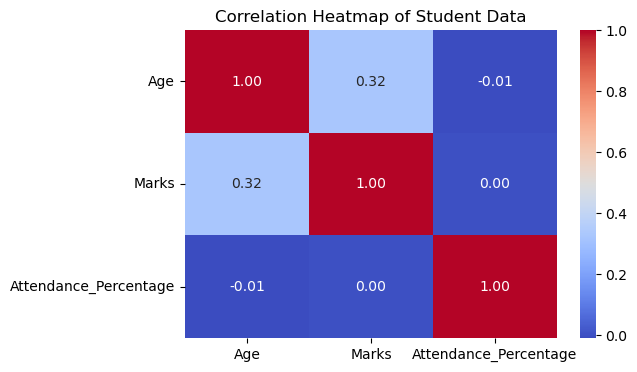

In [164]:
import seaborn as sns
# Select only numeric columns
numeric_df = df[['Age', 'Marks', 'Attendance_Percentage']]
# Calculate correlation matrix
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Student Data")
plt.show()